# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Marcus Teoh Zhoon Ye (2503577E)


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

**Use of Generative AI tools**

> ⚠️ **TODO — you must write this section yourself, honestly.** The specification says declaring Gen AI use does *not* cost you marks, but an inaccurate declaration is an academic offence. State plainly: which tool, what you used it for (e.g. scaffolding code, debugging, explaining concepts), and confirm that you reviewed and can defend every analytical decision. Delete this quote block once written.


# Libraries

In [1]:
## Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# One seed reused everywhere (splits, model init, CV, search) so that every number in
# this notebook is reproducible by the marker on a fresh run.
RANDOM_STATE = 42

# Show all columns; the dataset is only 12 wide so nothing needs truncating.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Consistent plot styling so every figure in the notebook reads as one report.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

print('pandas', pd.__version__, '| numpy', np.__version__)


pandas 3.0.3 | numpy 2.5.0


# 1. Business Understanding

**Goal:** predict `Item_Outlet_Sales` — the revenue a single product generates at a single outlet — so that a retail chain can plan inventory and evaluate outlet performance before the selling period, not after it.

This is a **regression** problem: the target is a continuous dollar amount, not a class.

**Who uses the prediction, and for what decision**

| Stakeholder | Decision the prediction supports |
|---|---|
| Inventory planner | How many units of this product to send to this outlet |
| Category manager | Which product types earn their shelf space |
| Outlet strategy | Which store formats and locations to open or invest in |

**The cost of being wrong is asymmetric in practice:** over-forecast and you tie up cash in stock that may spoil; under-forecast and you lose the sale outright. We return to this when choosing the evaluation metric in Section 6.

> ✏️ **TODO — expand this into your own paragraph.** Prompts, one line each:
> - Why a *retail chain* cares about per-product-per-store revenue rather than total sales
> - What they currently do instead (hint: a flat average — that is your naive baseline)
> - What a good-enough model unlocks in dollar terms, and what it does **not** solve


# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame

df = pd.read_csv('data/bigmart.csv')

print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()


Rows: 8,523   Columns: 12


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


The dataset is the BigMart Sales dataset (Kaggle mirror of the Analytics Vidhya practice problem): **8,523 rows x 12 columns** = 11 candidate features + 1 target. Each row is one *product observed at one outlet*, which is exactly the unit of the business decision above.

**Column meanings**

| Column | Meaning | Level |
|---|---|---|
| `Item_Identifier` | Product code (e.g. FDA15) | Product |
| `Item_Weight` | Product weight | Product |
| `Item_Fat_Content` | Low Fat / Regular | Product |
| `Item_Visibility` | Share of total display area given to this product | Product x Outlet |
| `Item_Type` | Product category (16 levels) | Product |
| `Item_MRP` | Maximum retail price | Product |
| `Outlet_Identifier` | Store code (10 stores) | Outlet |
| `Outlet_Establishment_Year` | Year store opened | Outlet |
| `Outlet_Size` | Small / Medium / High | Outlet |
| `Outlet_Location_Type` | Tier 1 / 2 / 3 city | Outlet |
| `Outlet_Type` | Grocery Store / Supermarket Type1-3 | Outlet |
| **`Item_Outlet_Sales`** | **Target — revenue for this product at this outlet** | Product x Outlet |


## 2.2 Summary Statistics

### 2.2.1 Type of variable for each column

Before any cleaning we establish what each column *is*, because the variable type decides the preprocessing: numeric columns need imputing and scaling, categorical columns need imputing and encoding.

In [3]:
## Understand the type of variable for each column

df.info()

# Cardinality matters as much as dtype here: a column stored as 'object' with 1,559
# distinct values is an identifier, not a usable category, and must be treated differently.
print('\nDistinct values per column:')
print(df.nunique().sort_values(ascending=False).to_string())


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB

Distinct values per column:
Item_Visibility              7880

### 2.2.2 Check for missing data

Missing values decide two things: whether a column is usable at all, and whether the imputation must be **fitted on the training set only** (it must — otherwise test-set information leaks into training).

In [4]:
## Check for missing data

missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
})
missing = missing[missing['n_missing'] > 0].sort_values('n_missing', ascending=False)

print('Columns with missing values:')
print(missing.to_string() if len(missing) else 'None')


Columns with missing values:
             n_missing  pct_missing
Outlet_Size       2410         28.3
Item_Weight       1463         17.2


### 2.2.3 Describe data distribution

Summary statistics for the numeric columns, including the target. We are looking for impossible values (a zero where zero cannot occur), and for skew in the target that would affect which error metric is honest.

In [5]:
## Describe data distribution

display(df.describe().T)

# The target deserves its own read: mean vs median tells us about skew, which affects
# both metric choice (Section 6) and whether a log transform is worth testing.
target = df['Item_Outlet_Sales']
print('Target: Item_Outlet_Sales')
print(f'  min     ${target.min():,.2f}')
print(f'  median  ${target.median():,.2f}')
print(f'  mean    ${target.mean():,.2f}')
print(f'  max     ${target.max():,.2f}')
print(f'  skew    {target.skew():.2f}   (0 = symmetric; > 1 = strong right tail)')


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


Target: Item_Outlet_Sales
  min     $33.29
  median  $1,794.33
  mean    $2,181.29
  max     $13,086.96
  skew    1.18   (0 = symmetric; > 1 = strong right tail)


### 2.2.4 Categorical levels — label consistency check

*(Added subsection.)* `df.info()` cannot tell us whether a categorical column uses **consistent labels**. If the same real-world category is spelled three different ways, one-hot encoding will create three separate columns for it and split the signal.

In [6]:
## Inspect every level of every categorical column

# pandas 3 stores text columns as the dedicated 'str' dtype, so select on that
# rather than the legacy 'object' alias (which now raises a deprecation warning).
categorical_cols = df.select_dtypes(include='str').columns

for col in categorical_cols:
    # Skip the two identifier columns - listing 1,559 product codes is not informative.
    if df[col].nunique() > 20:
        print(f'{col}: {df[col].nunique()} distinct values (identifier - not listed)\n')
        continue
    print(f'{col}  ({df[col].nunique()} levels)')
    print(df[col].value_counts().to_string())
    print()


Item_Identifier: 1559 distinct values (identifier - not listed)

Item_Fat_Content  (5 levels)
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112

Item_Type  (16 levels)
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64

Outlet_Identifier  (10 levels)
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528

Outlet_Size  (3 levels)
Outlet_Size
Medium    2793
Small     2388
High       932

Outlet_Location_Type  

### 2.2.5 Disguised missing values in `Item_Visibility`

*(Added subsection.)* `Item_Visibility` is the share of display area a product occupies. A product that is stocked and recorded as sold **cannot** occupy 0% of the shelf. Any zero here is therefore a missing value written as a number — the kind that `isna()` will never flag and that silently drags the feature's distribution toward zero.

In [7]:
## Quantify the disguised-missing problem in Item_Visibility

n_zero = (df['Item_Visibility'] == 0).sum()
print(f'Rows with Item_Visibility == 0 : {n_zero:,}  ({n_zero / len(df) * 100:.1f}%)')

# Proof that these are not genuine zeros: the products concerned still recorded sales.
zero_rows = df[df['Item_Visibility'] == 0]
print(f'...of those, rows with sales > 0 : {(zero_rows["Item_Outlet_Sales"] > 0).sum():,}')
print(f'   their median sales           : ${zero_rows["Item_Outlet_Sales"].median():,.2f}')
print(f'   median sales, all other rows : '
      f'${df.loc[df["Item_Visibility"] > 0, "Item_Outlet_Sales"].median():,.2f}')


Rows with Item_Visibility == 0 : 526  (6.2%)
...of those, rows with sales > 0 : 526
   their median sales           : $1,774.02
   median sales, all other rows : $1,794.33


### 2.2.6 Identifier columns and the leakage risk they carry

*(Added subsection.)* `Outlet_Identifier` has only 10 levels, so it is *tempting* to one-hot encode it. The check below shows why that is a trap for this business problem: the 10 stores have very different average sales, so the identifier would let the model memorise each store's historical average instead of learning **why** stores differ (size, type, location, age).

That distinction matters commercially: a model keyed to store IDs cannot answer *'what would a new Tier-2 supermarket sell?'* — which is the outlet-strategy question in Section 1.

In [8]:
## Why Outlet_Identifier is excluded despite having only 10 levels

outlet_profile = (
    df.groupby('Outlet_Identifier')
      .agg(n_rows=('Item_Outlet_Sales', 'size'),
           mean_sales=('Item_Outlet_Sales', 'mean'),
           outlet_type=('Outlet_Type', 'first'),
           outlet_size=('Outlet_Size', lambda s: s.iloc[0] if s.notna().any() else 'missing'),
           location=('Outlet_Location_Type', 'first'))
      .sort_values('mean_sales', ascending=False)
      .round(1)
)
display(outlet_profile)

# If mean sales are almost perfectly explained by Outlet_Type, then Outlet_Type carries
# the same signal in a form that generalises to outlets the model has never seen.
print('Mean sales by Outlet_Type (the generalisable version of the same signal):')
print(df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().round(1).to_string())


,n_rows,mean_sales,outlet_type,outlet_size,location
Outlet_Identifier,,,,,
OUT027,935,3694.0,Supermarket Type3,Medium,Tier 3
OUT035,930,2438.8,Supermarket Type1,Small,Tier 2
OUT049,930,2348.4,Supermarket Type1,Medium,Tier 1
OUT017,926,2340.7,Supermarket Type1,missing,Tier 2
OUT013,932,2299.0,Supermarket Type1,High,Tier 3
OUT046,930,2277.8,Supermarket Type1,Small,Tier 1
OUT045,929,2192.4,Supermarket Type1,missing,Tier 2
OUT018,928,1995.5,Supermarket Type2,Medium,Tier 3
OUT019,528,340.3,Grocery Store,Small,Tier 1


Mean sales by Outlet_Type (the generalisable version of the same signal):
Outlet_Type
Grocery Store         339.8
Supermarket Type1    2316.2
Supermarket Type2    1995.5
Supermarket Type3    3694.0


### 2.2.7 Is the missing data actually random?

*(Added subsection.)* Standard practice is to impute a missing category with its mode. That is only defensible if the values are missing more or less at random. Before accepting it, we check **where** the missingness sits — because if it is concentrated in a few outlets, the mode is imputing a fact about *other* stores onto stores it does not describe.

The same question for `Item_Weight`: is a product's weight missing at random, or missing for particular products (in which case another row for the *same product* may carry the true weight, and a per-product lookup beats a global median)?

In [9]:
## Where does the missingness actually sit?

# Outlet_Size: count missing rows per outlet. If whole outlets are missing, the
# missingness is structural (an unrecorded store attribute), not random noise.
size_missing = (
    df.assign(size_missing=df['Outlet_Size'].isna())
      .groupby('Outlet_Identifier')
      .agg(n_rows=('size_missing', 'size'),
           n_missing=('size_missing', 'sum'),
           outlet_type=('Outlet_Type', 'first'),
           location=('Outlet_Location_Type', 'first'))
)
print('Outlet_Size missingness by outlet (only outlets with any missing shown):')
print(size_missing[size_missing['n_missing'] > 0].to_string())
print(f"\nOutlets fully missing a size: "
      f"{(size_missing['n_missing'] == size_missing['n_rows']).sum()} of {len(size_missing)}")

# Item_Weight: is the weight recoverable from another row for the SAME product?
weight_by_item = df.groupby('Item_Identifier')['Item_Weight'].nunique(dropna=True)
items_missing = df.loc[df['Item_Weight'].isna(), 'Item_Identifier'].unique()
recoverable = sum(weight_by_item.get(i, 0) > 0 for i in items_missing)
print(f'\nProducts with a missing weight somewhere : {len(items_missing):,}')
print(f'...of which the weight IS recorded on another row : {recoverable:,}')
print(f'Max distinct weights recorded for any one product : {weight_by_item.max()} '
      f'(1 = weight is a stable product attribute)')


Outlet_Size missingness by outlet (only outlets with any missing shown):
                   n_rows  n_missing        outlet_type location
Outlet_Identifier                                               
OUT010                555        555      Grocery Store   Tier 3
OUT017                926        926  Supermarket Type1   Tier 2
OUT045                929        929  Supermarket Type1   Tier 2

Outlets fully missing a size: 3 of 10

Products with a missing weight somewhere : 1,142
...of which the weight IS recorded on another row : 1,138
Max distinct weights recorded for any one product : 1 (1 = weight is a stable product attribute)


### 2.2.8 Data-quality findings and the resulting cleaning plan

> ✏️ **TODO — fill this table in from YOUR outputs above, then write two sentences under it.** Do not copy numbers you have not seen printed. Prompts:
> - For each issue: what is wrong, how big is it (%), and is the fix **deterministic** >   (a rule that needs no data, e.g. relabelling `LF` to `Low Fat`) or **fitted** >   (needs a statistic learned from data, e.g. a median — therefore must go inside the >   pipeline and be fitted on train only)?
> - Which single issue would most distort the model if left alone, and why?

| # | Issue | Column | Size | Fix | Deterministic or fitted? |
|---|---|---|---|---|---|
| 1 | Inconsistent labels | `Item_Fat_Content` | ? | | |
| 2 | Zeros that mean 'missing' | `Item_Visibility` | ? | | |
| 3 | Missing values | `Item_Weight` | ? | | |
| 4 | Missing values | `Outlet_Size` | ? | | |
| 5 | High-cardinality identifiers | `Item_Identifier`, `Outlet_Identifier` | ? | | |


## 2.3 Data Visualization

Everything below is plotted on the **raw** data, before any cleaning. That is deliberate: the plots are the evidence for the cleaning decisions taken in Section 3, so they have to show the problems rather than hide them.

### 2.3.1 Understanding distribution of data

#### 2.3.1.1 Understanding distribution of target

The shape of the target decides two later choices: whether a log transform is worth testing, and whether RMSE (which punishes large misses quadratically) or MAE (which treats every dollar equally) is the fairer headline metric.

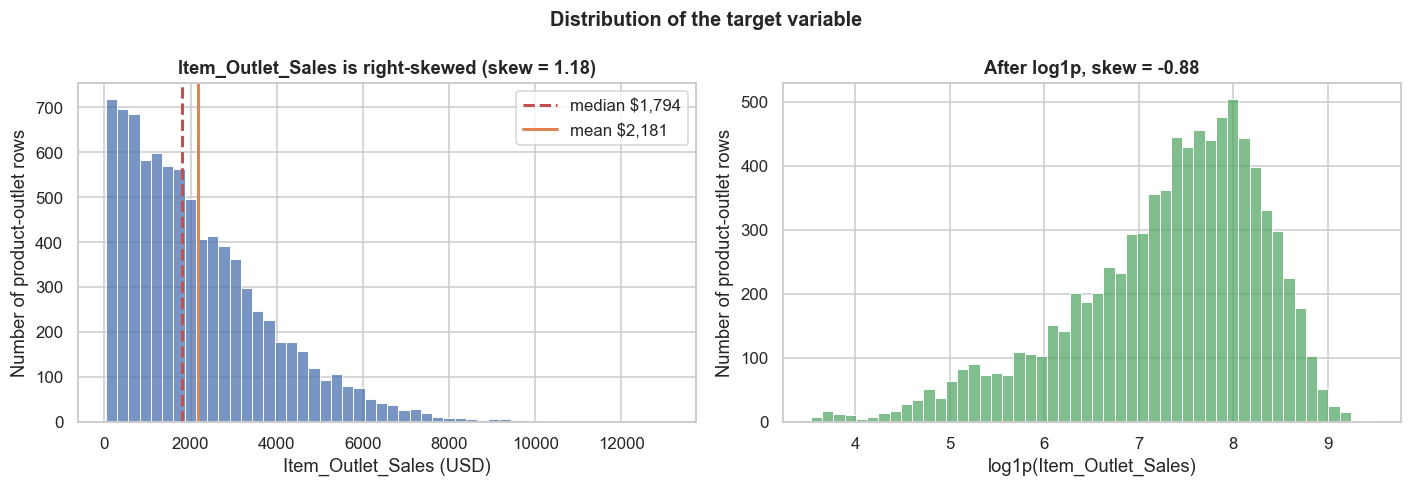

99th percentile: $7,366.01   max: $13,086.96
Rows above the 99th percentile: 86 (1.0%)


In [10]:
## Understanding distribution of target

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: raw target. Right: log1p, to check whether the skew is a simple scale effect.
sns.histplot(df['Item_Outlet_Sales'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].axvline(df['Item_Outlet_Sales'].median(), color='#C44E52', ls='--', lw=2,
                label=f"median ${df['Item_Outlet_Sales'].median():,.0f}")
axes[0].axvline(df['Item_Outlet_Sales'].mean(), color='#DD8452', ls='-', lw=2,
                label=f"mean ${df['Item_Outlet_Sales'].mean():,.0f}")
axes[0].set_title(f"Item_Outlet_Sales is right-skewed (skew = {df['Item_Outlet_Sales'].skew():.2f})")
axes[0].set_xlabel('Item_Outlet_Sales (USD)')
axes[0].set_ylabel('Number of product-outlet rows')
axes[0].legend()

sns.histplot(np.log1p(df['Item_Outlet_Sales']), bins=50, ax=axes[1], color='#55A868')
axes[1].set_title(f"After log1p, skew = {np.log1p(df['Item_Outlet_Sales']).skew():.2f}")
axes[1].set_xlabel('log1p(Item_Outlet_Sales)')
axes[1].set_ylabel('Number of product-outlet rows')

fig.suptitle('Distribution of the target variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify the tail rather than eyeballing it - needed to argue about outliers.
q99 = df['Item_Outlet_Sales'].quantile(0.99)
print(f"99th percentile: ${q99:,.2f}   max: ${df['Item_Outlet_Sales'].max():,.2f}")
print(f"Rows above the 99th percentile: {(df['Item_Outlet_Sales'] > q99).sum()} "
      f"({(df['Item_Outlet_Sales'] > q99).mean() * 100:.1f}%)")


> ✏️ **TODO — your interpretation.** Prompts:
> - What a right tail means commercially (a few product-store pairs are blockbusters)
> - Are the high values *errors* or *real business events*? What follows for outlier removal?
> - Given the tail, does the chain care more about being wrong on a $10,000 line or a >   $200 line? Link this to your metric choice in Section 6


#### 2.3.1.2 Understanding distribution of features

Numeric features first. We are checking for impossible values and for shapes that will need scaling before a linear model can use them fairly.

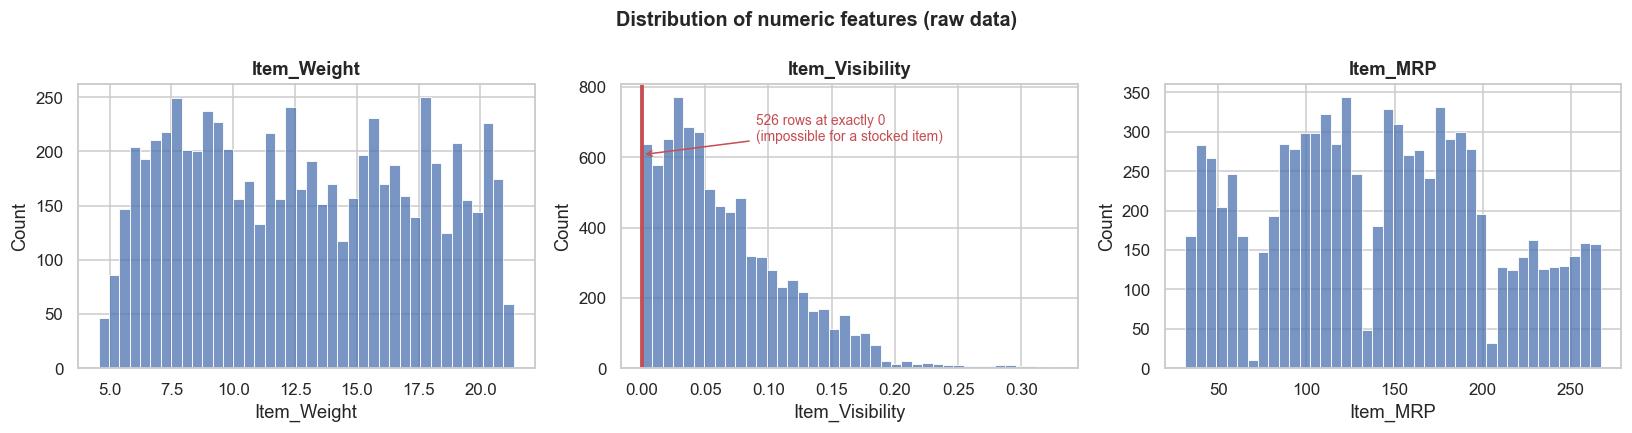

In [11]:
## Understanding distribution of numeric features

numeric_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], bins=40, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Mark the impossible-zero spike found in 2.2.5 so the problem is visible, not just stated.
n_zero = (df['Item_Visibility'] == 0).sum()
axes[1].axvline(0, color='#C44E52', lw=2.5)
axes[1].annotate(f'{n_zero} rows at exactly 0\n(impossible for a stocked item)',
                 xy=(0, axes[1].get_ylim()[1] * 0.75),
                 xytext=(0.09, axes[1].get_ylim()[1] * 0.8),
                 color='#C44E52', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='#C44E52'))

fig.suptitle('Distribution of numeric features (raw data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


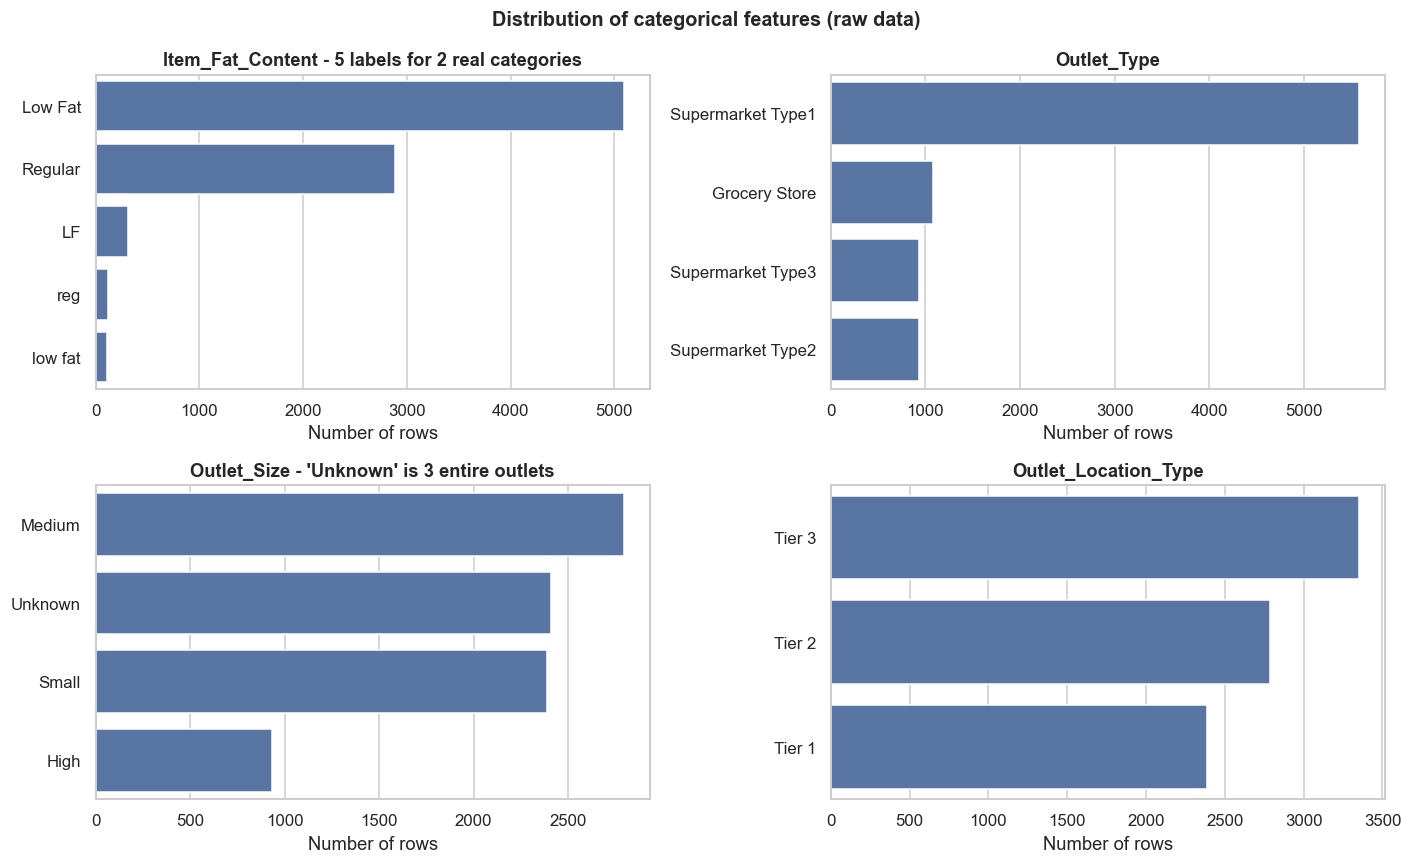

In [12]:
## Understanding distribution of categorical features

# Outlet_Size is shown with its missing values made visible rather than silently dropped,
# because 'not recorded' is itself the finding from 2.2.7.
plot_df = df.copy()
plot_df['Outlet_Size'] = plot_df['Outlet_Size'].fillna('Unknown')

cat_features = ['Item_Fat_Content', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.ravel(), cat_features):
    order = plot_df[col].value_counts().index
    sns.countplot(data=plot_df, y=col, order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('Number of rows')
    ax.set_ylabel('')

axes.ravel()[0].set_title('Item_Fat_Content - 5 labels for 2 real categories')
axes.ravel()[2].set_title("Outlet_Size - 'Unknown' is 3 entire outlets")
fig.suptitle('Distribution of categorical features (raw data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> ✏️ **TODO — your interpretation.** Prompts:
> - `Item_Visibility`: why a zero cannot be genuine, and what imputing it wrongly would do
> - `Item_MRP`: describe the shape you see — is it one population or several?
> - `Item_Fat_Content`: what happens to a one-hot encoder if the 5 labels are left as-is
> - Class balance across `Outlet_Type`: is any level rare enough to worry about?


### 2.3.2 Understanding relationship between variables

Distribution tells us what each column *is*; this section asks which columns actually move revenue. That ranking is what drives feature selection in Section 4.

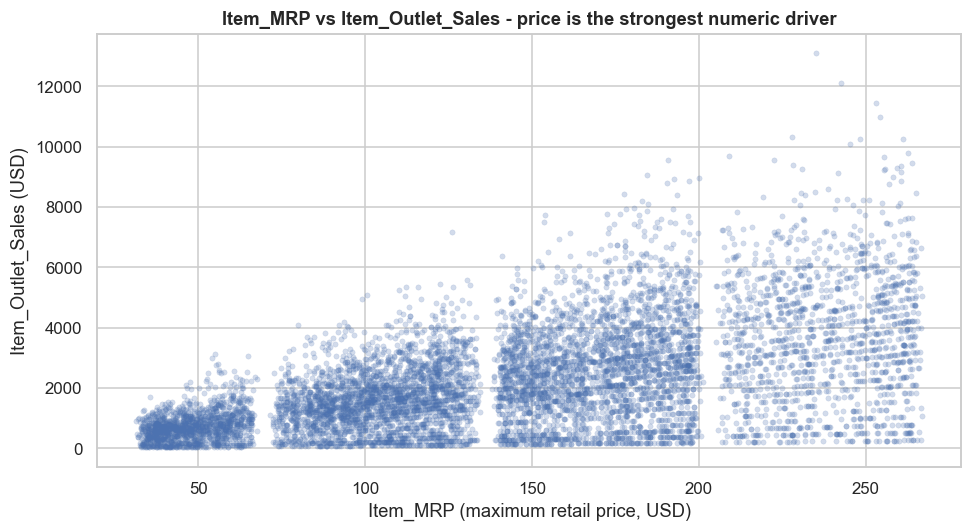

Pearson correlation, Item_MRP vs Item_Outlet_Sales: 0.568


In [13]:
## Relationship: Item_MRP vs Item_Outlet_Sales

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales',
                alpha=0.25, s=12, ax=ax, color='#4C72B0', edgecolor=None)
ax.set_title('Item_MRP vs Item_Outlet_Sales - price is the strongest numeric driver')
ax.set_xlabel('Item_MRP (maximum retail price, USD)')
ax.set_ylabel('Item_Outlet_Sales (USD)')
plt.tight_layout()
plt.show()

r = df['Item_MRP'].corr(df['Item_Outlet_Sales'])
print(f'Pearson correlation, Item_MRP vs Item_Outlet_Sales: {r:.3f}')


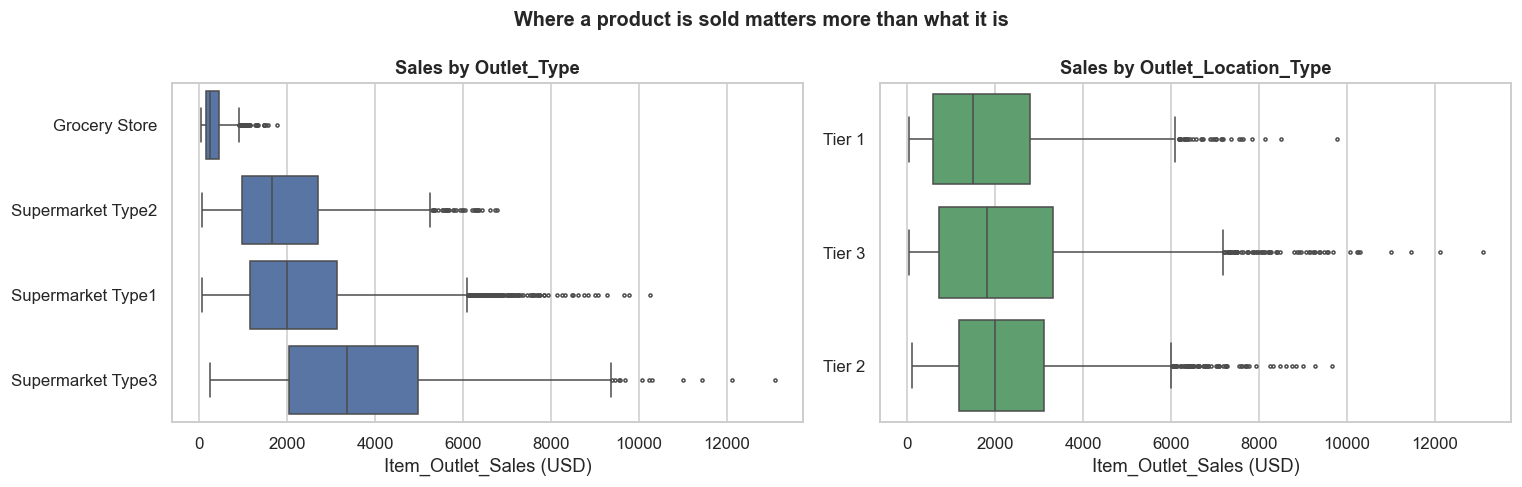

Median sales by Outlet_Type:
                   count  median    mean
Outlet_Type                             
Grocery Store       1083   257.0   339.8
Supermarket Type1   5577  1990.7  2316.2
Supermarket Type2    928  1655.2  1995.5
Supermarket Type3    935  3365.0  3694.0


In [14]:
## Relationship: sales by outlet attributes

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order_type = df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Type', order=order_type,
            ax=axes[0], color='#4C72B0', fliersize=2)
axes[0].set_title('Sales by Outlet_Type')
axes[0].set_xlabel('Item_Outlet_Sales (USD)')
axes[0].set_ylabel('')

order_loc = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Location_Type', order=order_loc,
            ax=axes[1], color='#55A868', fliersize=2)
axes[1].set_title('Sales by Outlet_Location_Type')
axes[1].set_xlabel('Item_Outlet_Sales (USD)')
axes[1].set_ylabel('')

fig.suptitle('Where a product is sold matters more than what it is',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median sales by Outlet_Type:')
print(df.groupby('Outlet_Type')['Item_Outlet_Sales'].agg(['count', 'median', 'mean'])
        .round(1).to_string())


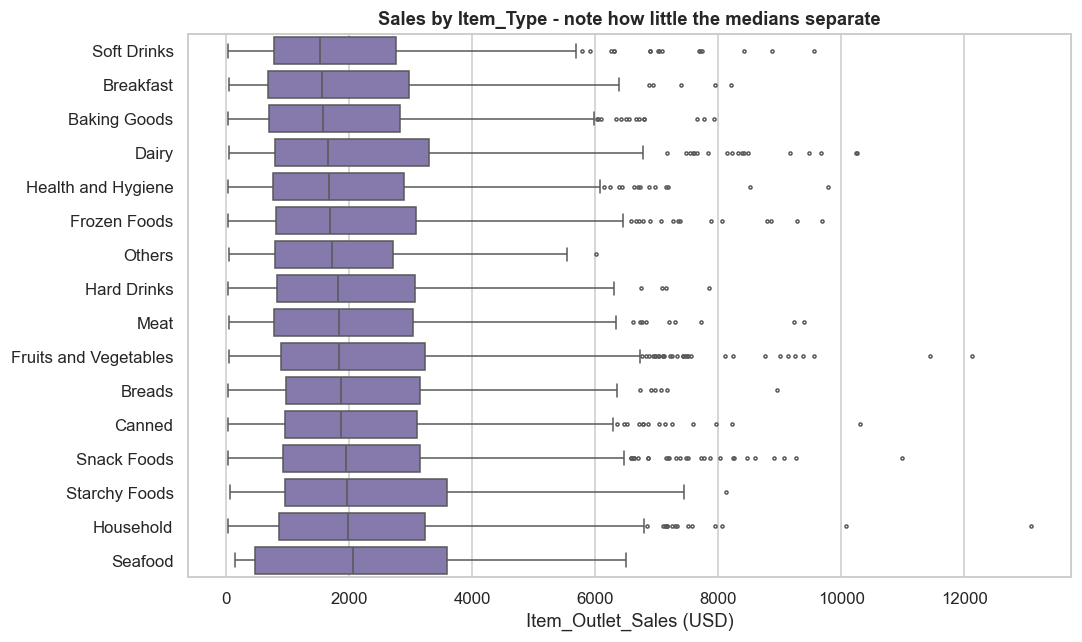

Median sales range across the 16 Item_Type levels: $1,518 to $2,055
Median sales range across the 4 Outlet_Type levels : $257 to $3,365


In [15]:
## Relationship: sales by product category

fig, ax = plt.subplots(figsize=(10, 6))
order_item = df.groupby('Item_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Item_Type', order=order_item,
            ax=ax, color='#8172B3', fliersize=2)
ax.set_title('Sales by Item_Type - note how little the medians separate')
ax.set_xlabel('Item_Outlet_Sales (USD)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

spread = df.groupby('Item_Type')['Item_Outlet_Sales'].median()
print(f'Median sales range across the 16 Item_Type levels: '
      f'${spread.min():,.0f} to ${spread.max():,.0f}')
print(f'Median sales range across the 4 Outlet_Type levels : '
      f"${df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().min():,.0f} to "
      f"${df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().max():,.0f}")


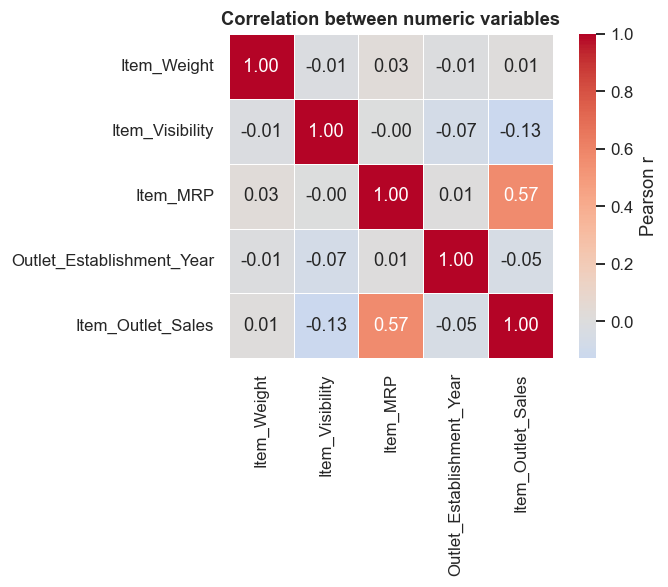

Correlation with the target, strongest first:
Item_MRP                     0.568
Item_Visibility             -0.129
Outlet_Establishment_Year   -0.049
Item_Weight                  0.014


In [16]:
## Correlation between numeric variables

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation between numeric variables', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with the target, strongest first:')
print(corr['Item_Outlet_Sales'].drop('Item_Outlet_Sales')
          .sort_values(key=abs, ascending=False).round(3).to_string())


#### 2.3.2.1 Ranking every feature by how much of the sales variance it explains

*(Added subsection.)* Pearson correlation only works for numeric columns, so it cannot compare `Item_MRP` against `Outlet_Type`. **Eta-squared** can: it is the share of total sales variance that lies *between* a column's groups rather than within them, on the same 0-1 scale for numeric and categorical features alike. This gives one honest ranking to justify feature selection in Section 4.

,feature,kind,eta_squared
0,Item_MRP,numeric (binned),0.3189
1,Outlet_Type,categorical,0.2396
2,Outlet_Establishment_Year,numeric (binned),0.0871
3,Outlet_Size,categorical,0.0482
4,Item_Visibility,numeric (binned),0.0173
5,Outlet_Location_Type,categorical,0.0125
6,Item_Type,categorical,0.0047
7,Item_Weight,numeric (binned),0.0015
8,Item_Fat_Content,categorical,0.0004


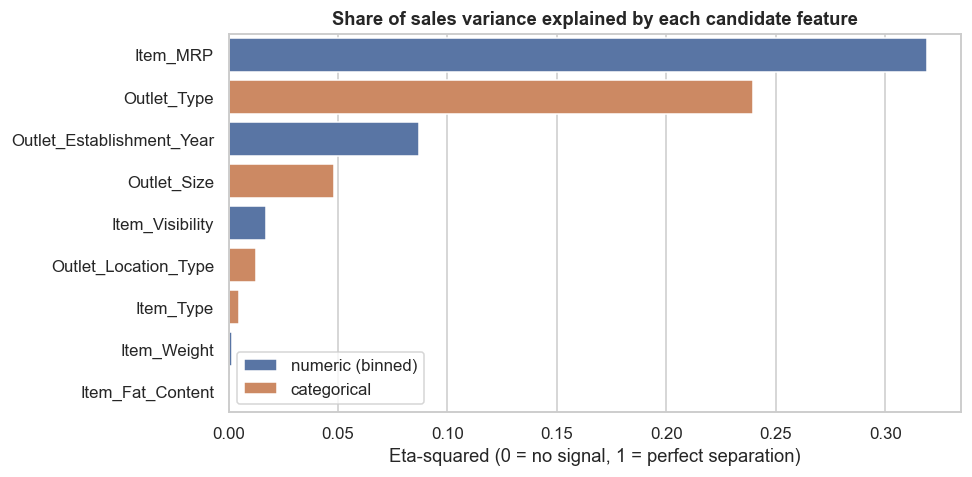

In [17]:
## Rank all candidate features by variance explained (eta-squared)

def eta_squared(frame, feature, target='Item_Outlet_Sales'):
    """Share of total variance in `target` explained by group membership in `feature`.

    0 = the groups all have the same mean (no signal);
    1 = every group is internally identical (perfect separation).
    """
    groups = frame.groupby(feature, observed=True)[target]
    grand_mean = frame[target].mean()
    ss_between = (groups.count() * (groups.mean() - grand_mean) ** 2).sum()
    ss_total = ((frame[target] - grand_mean) ** 2).sum()
    return ss_between / ss_total

# Descriptive only: the two deterministic fixes are applied to a COPY so the ranking is
# not distorted by split labels. The real transformation is defined in Section 3 and
# lives inside the pipeline, never as a mutation of `df`.
tidy = df.copy()
tidy['Item_Fat_Content'] = tidy['Item_Fat_Content'].replace(
    {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})
tidy['Outlet_Size'] = tidy['Outlet_Size'].fillna('Unknown')

# Numeric features are binned into deciles so the same statistic applies to every column.
rows = []
for col in ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']:
    rows.append({'feature': col, 'kind': 'categorical',
                 'eta_squared': eta_squared(tidy, col)})

for col in ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']:
    binned = tidy.assign(_bin=pd.qcut(tidy[col], 10, duplicates='drop'))
    rows.append({'feature': col, 'kind': 'numeric (binned)',
                 'eta_squared': eta_squared(binned.dropna(subset=['_bin']), '_bin')})

signal = (pd.DataFrame(rows)
            .sort_values('eta_squared', ascending=False)
            .reset_index(drop=True))
signal['eta_squared'] = signal['eta_squared'].round(4)
display(signal)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=signal, x='eta_squared', y='feature', hue='kind',
            dodge=False, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Share of sales variance explained by each candidate feature',
             fontweight='bold')
ax.set_xlabel('Eta-squared (0 = no signal, 1 = perfect separation)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()


### EDA summary — implications for modelling

> ✏️ **TODO — write 4-6 bullets, each ending in a modelling consequence.** This block is where the 8% EDA mark is actually won: the rubric asks for business-relevant interpretation *and* stated implications for modelling. Prompts:
> - Which two features dominate the eta-squared ranking, and what that says about whether >   revenue is driven by *the product* or *the store*
> - `Item_Type` has 16 levels but a narrow median range — is it worth 16 one-hot columns?
> - The `Item_MRP` scatter: describe the structure, and say whether a **linear** model can >   capture it or whether that argues for tree-based models
> - Why `Outlet_Establishment_Year` should become an age rather than stay a raw year
> - What the right tail of the target implies for the metric you lead with
> - One thing the data does **not** contain that a real forecaster would want >   (footfall? promotions? competitor pricing?) — this is your honest-limitations line >   for the pitch


# 3. Data Preparation

## 3.1 Data Cleaning

Every cleaning rule below is classified as **deterministic** or **fitted**, because that classification decides *where the code is allowed to live*:

| Kind | Definition | Where it must run |
|---|---|---|
| **Deterministic** | A fixed rule needing no statistic from the data (e.g. `LF` → `Low Fat`) | Anywhere — it cannot leak |
| **Fitted** | Needs a value *learned* from data (e.g. a median, a category list) | Inside the `Pipeline`, fitted on the training split only |

Getting this wrong is the single most common way to produce an inflated score: computing a median over all 8,523 rows and *then* splitting means the test rows helped choose the value used to fill them. We quantify that effect in Section 7.

### 3.1.1 Evidence for the non-edible rule

Section 2.2.4 showed all `Item_Fat_Content` values collapse to `Low Fat` / `Regular`. But the `Item_Identifier` prefix encodes something the fat label ignores: `FD` = food, `DR` = drink, `NC` = non-consumable. Calling a household cleaning product *'Low Fat'* is meaningless, and it lets the encoder treat soap and yoghurt as the same kind of thing.

The check below decides **which column the rule should key off**. The Streamlit app collects `Item_Type` but has no product code, so if `Item_Type` identifies the non-consumables exactly, the rule works identically in training and in the app.

In [18]:
## Does Item_Type identify the non-consumables exactly?

prefix = df['Item_Identifier'].str[:2]
crosstab = pd.crosstab(df['Item_Type'], prefix)
display(crosstab)

nc_types = sorted(crosstab.index[crosstab['NC'] > 0].tolist())
# 'Exclusive' means those Item_Types contain NC rows and nothing else - if so, the
# mapping is one-to-one and Item_Type is a safe substitute for the identifier prefix.
exclusive = crosstab.loc[nc_types].drop(columns='NC').to_numpy().sum() == 0

print(f'Item_Types under the NC prefix : {nc_types}')
print(f'Are those types exclusively NC? : {exclusive}')
print(f'Rows affected                   : {(prefix == "NC").sum():,}')
print('\nFat content currently recorded on those non-consumable rows:')
print(df.loc[prefix == 'NC', 'Item_Fat_Content'].value_counts().to_string())


Item_Identifier,DR,FD,NC
Item_Type,,,
Baking Goods,0,648,0
Breads,0,251,0
Breakfast,0,110,0
Canned,0,649,0
Dairy,140,542,0
Frozen Foods,0,856,0
Fruits and Vegetables,0,1232,0
Hard Drinks,214,0,0
Health and Hygiene,0,0,520


Item_Types under the NC prefix : ['Health and Hygiene', 'Household', 'Others']
Are those types exclusively NC? : True
Rows affected                   : 1,599

Fat content currently recorded on those non-consumable rows:
Item_Fat_Content
Low Fat    1477
LF           94
low fat      28


### 3.1.2 The preprocessing module

The transformations are written to `bigmart_preprocessing.py` rather than defined inline. Two reasons, both practical:

1. **The Streamlit app imports this same file.** Preprocessing cannot drift apart from    the model, because there is only one copy of it.
2. **Pickled pipelines need importable code.** A transformer defined in a notebook cell    cannot be reloaded by `joblib.load()` inside another process.

Note which rules are *fitted*: `ItemWeightImputer` builds its lookup table in `fit()`, so it only ever sees training rows.

In [19]:
%%writefile bigmart_preprocessing.py
"""Preprocessing for the BigMart sales model.

Imported by BOTH the notebook and the Streamlit app so that a row is transformed
identically in training and in production. Anything that needs a value learned from
data is a scikit-learn transformer, so it can be fitted on the training split only.
"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# The BigMart data was collected in 2013. Outlet age is measured against that year so
# the feature keeps the same meaning when the app runs in a later calendar year - if
# the app used the real current year, every outlet would look older than anything the
# model was trained on, and the model would be extrapolating.
DATA_YEAR = 2013

# Five spellings, two real categories (notebook 2.2.4).
FAT_CONTENT_MAP = {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}

# Verified in notebook 3.1.1: these three Item_Types are exactly the 'NC' (non-consumable)
# identifier prefix, and nothing else. Keying off Item_Type instead of Item_Identifier
# lets the Streamlit app apply the identical rule without asking for a product code.
NON_EDIBLE_ITEM_TYPES = ('Health and Hygiene', 'Household', 'Others')
NON_EDIBLE_LABEL = 'Non-Edible'

# The full candidate feature set. Outlet_Age replaces the raw establishment year;
# the identifier columns are deliberately absent (see notebook 2.2.6).
NUMERIC_FEATURES = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
CATEGORICAL_FEATURES = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
                        'Outlet_Location_Type', 'Outlet_Type']


def clean_deterministic(X):
    """Fixed rules that need no statistic from the data, so they cannot leak.

    Safe to apply before the train/test split, but kept inside the pipeline anyway so
    that a raw row from the app travels the exact same path as a training row.
    """
    X = X.copy()

    # 1. Collapse the five fat-content spellings into the two real categories.
    X['Item_Fat_Content'] = X['Item_Fat_Content'].replace(FAT_CONTENT_MAP)

    # 2. Fat content is meaningless for cleaning products and toiletries. Give them
    #    their own label instead of letting 1,599 rows masquerade as 'Low Fat' food.
    is_non_edible = X['Item_Type'].isin(NON_EDIBLE_ITEM_TYPES)
    X.loc[is_non_edible, 'Item_Fat_Content'] = NON_EDIBLE_LABEL

    # 3. A stocked item that recorded sales cannot occupy 0%% of the shelf. Convert the
    #    disguised missing value into a real NaN so the fitted imputer handles it.
    X['Item_Visibility'] = X['Item_Visibility'].replace(0.0, np.nan)

    # 4. Three outlets have no size on record at all (notebook 2.2.7). Saying so is
    #    honest; imputing the mode would invent a measurement for 28%% of rows.
    X['Outlet_Size'] = X['Outlet_Size'].fillna('Unknown')

    # 5. Feature engineering: years trading is the business quantity a planner reasons
    #    about, and it is monotonic, unlike a raw calendar year.
    X['Outlet_Age'] = DATA_YEAR - X['Outlet_Establishment_Year']

    return X


class ItemWeightImputer(BaseEstimator, TransformerMixin):
    """Recover a missing Item_Weight from the same product measured at another outlet.

    Notebook 2.2.7 established that weight is a stable product attribute (at most one
    distinct weight per product) and that 1,138 of the 1,142 affected products have it
    recorded on another row. A per-product lookup therefore recovers almost all of them,
    where a global median would discard that information.

    The lookup table is built in fit(), so it is learned from the training split only.
    Falls back to the training median for products never seen (and works unchanged when
    Item_Identifier is absent, as it is in the Streamlit app).
    """

    def fit(self, X, y=None):
        if 'Item_Identifier' in X.columns:
            self.weight_by_item_ = (
                X.groupby('Item_Identifier')['Item_Weight'].median().dropna()
            )
        else:
            self.weight_by_item_ = pd.Series(dtype=float)
        self.global_median_ = X['Item_Weight'].median()
        return self

    def transform(self, X):
        X = X.copy()
        if 'Item_Identifier' in X.columns and len(self.weight_by_item_):
            recovered = X['Item_Identifier'].map(self.weight_by_item_)
            X['Item_Weight'] = X['Item_Weight'].fillna(recovered)
        X['Item_Weight'] = X['Item_Weight'].fillna(self.global_median_)
        return X


def build_preprocessor(numeric_features, categorical_features):
    """Impute + scale the numerics, impute + one-hot the categoricals.

    Every step here is fitted, so it must sit inside the pipeline. Columns not named
    (the identifiers, the raw establishment year) are removed by remainder='drop'.
    StandardScaler is needed by Linear Regression and is harmless to the tree models,
    so one preprocessor can serve every candidate model.
    """
    numeric_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        # handle_unknown='ignore' stops the app crashing if it is ever sent a category
        # the training split never contained.
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        [
            ('num', numeric_pipe, list(numeric_features)),
            ('cat', categorical_pipe, list(categorical_features)),
        ],
        remainder='drop',
    )


def build_pipeline(model, numeric_features=NUMERIC_FEATURES,
                   categorical_features=CATEGORICAL_FEATURES):
    """The complete path from a raw BigMart row to a prediction."""
    return Pipeline([
        ('clean', FunctionTransformer(clean_deterministic, validate=False)),
        ('weight', ItemWeightImputer()),
        ('prep', build_preprocessor(numeric_features, categorical_features)),
        ('model', model),
    ])


Overwriting bigmart_preprocessing.py


In [20]:
## Import the module and confirm the cleaning rules do what 3.1.1 claimed

import importlib
import bigmart_preprocessing as bp
importlib.reload(bp)  # picks up the file just written, even on a re-run

cleaned_preview = bp.clean_deterministic(df)

print('Item_Fat_Content BEFORE cleaning:')
print(df['Item_Fat_Content'].value_counts().to_string())
print('\nItem_Fat_Content AFTER cleaning:')
print(cleaned_preview['Item_Fat_Content'].value_counts().to_string())

print(f"\nItem_Visibility zeros  before: {(df['Item_Visibility'] == 0).sum():,}"
      f"   after: {(cleaned_preview['Item_Visibility'] == 0).sum():,}"
      f"   (now NaN: {cleaned_preview['Item_Visibility'].isna().sum():,})")
print(f"Outlet_Size missing    before: {df['Outlet_Size'].isna().sum():,}"
      f"   after: {cleaned_preview['Outlet_Size'].isna().sum():,}"
      f"   ('Unknown': {(cleaned_preview['Outlet_Size'] == 'Unknown').sum():,})")
print(f"Outlet_Age created     range : {cleaned_preview['Outlet_Age'].min()}"
      f" to {cleaned_preview['Outlet_Age'].max()} years")


Item_Fat_Content BEFORE cleaning:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112

Item_Fat_Content AFTER cleaning:
Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599

Item_Visibility zeros  before: 526   after: 0   (now NaN: 526)
Outlet_Size missing    before: 2,410   after: 0   ('Unknown': 2,410)
Outlet_Age created     range : 4 to 28 years


## 3.2 Feature Engineering

**`Outlet_Age` = 2013 − `Outlet_Establishment_Year`.** The raw year is a label; the age is a quantity. A planner asks *'how long has this store been trading?'*, not *'was it opened in 1997?'* — and age is monotonic, so a linear model can actually use it.

**A feature deliberately *not* built:** `Item_Category` (Food / Drink / Non-Consumable) from the identifier prefix. It is a strict coarsening of `Item_Type`, which is already encoded, so it can carry no information `Item_Type` lacks. The granularity question it would answer is tested directly in Section 3.5 instead, by removing `Item_Type` altogether.

,n_rows,mean_sales,outlet_types
Outlet_Age,,,
4,928,1995.5,1
6,926,2340.7,1
9,930,2438.8,1
11,929,2192.4,1
14,930,2348.4,1
15,555,339.4,1
16,930,2277.8,1
26,932,2299.0,1
28,1463,2483.7,2


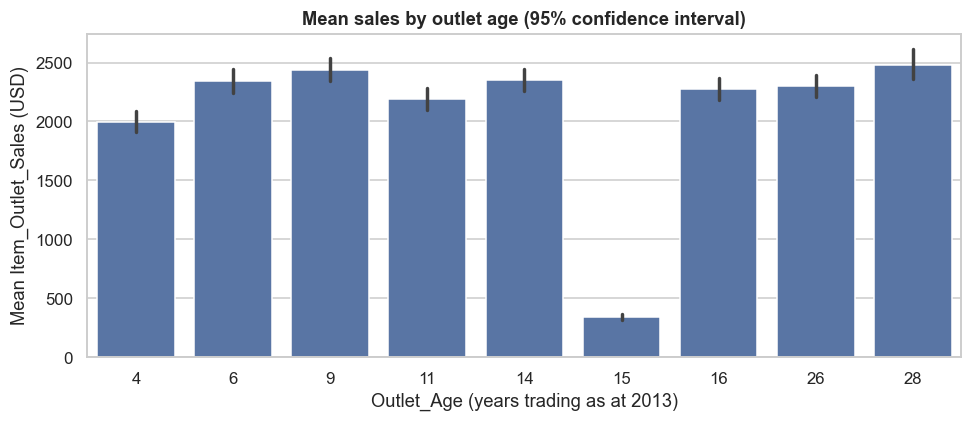

In [21]:
## Does Outlet_Age carry signal, and is it better behaved than the raw year?

age_profile = (cleaned_preview
               .groupby('Outlet_Age')
               .agg(n_rows=('Item_Outlet_Sales', 'size'),
                    mean_sales=('Item_Outlet_Sales', 'mean'),
                    outlet_types=('Outlet_Type', lambda s: s.nunique()))
               .round(1))
display(age_profile)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=cleaned_preview, x='Outlet_Age', y='Item_Outlet_Sales',
            errorbar=('ci', 95), ax=ax, color='#4C72B0')
ax.set_title('Mean sales by outlet age (95% confidence interval)', fontweight='bold')
ax.set_xlabel('Outlet_Age (years trading as at 2013)')
ax.set_ylabel('Mean Item_Outlet_Sales (USD)')
plt.tight_layout()
plt.show()


> ✏️ **TODO — your interpretation.** Prompts:
> - Is the age-sales relationship monotonic (older always sells more/less), or is one age >   group an outlier? Look at which `Outlet_Type` sits in the extreme group before >   concluding that *age itself* causes the difference
> - This is a confounding trap worth naming out loud in the pitch — say what it is


## 3.3 Train-Test Split

The split happens **before** anything is fitted. From here on, `X_test` is untouchable: it is looked at exactly once, in Section 7, to report the final honest score.

80/20 with a fixed seed. `Item_Identifier` is kept in `X` so `ItemWeightImputer` can use it; the `ColumnTransformer` drops it before it ever reaches a model.

In [22]:
## Split data into train set and test set

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')
print(f'Train mean sales: ${y_train.mean():,.2f}   Test mean sales: ${y_test.mean():,.2f}')
# The two means should be close; a large gap would mean the split happened to be unlucky
# and every downstream comparison would be measuring that instead of model quality.
print(f'Difference: ${abs(y_train.mean() - y_test.mean()):,.2f} '
      f'({abs(y_train.mean() - y_test.mean()) / y_train.mean() * 100:.2f}% of train mean)')


Train: 6,818 rows   Test: 1,705 rows
Train mean sales: $2,202.37   Test mean sales: $2,097.01
Difference: $105.36 (4.78% of train mean)


## 3.4 Preprocessing Pipeline

`Pipeline` + `ColumnTransformer` means preprocessing travels *with* the model. When the Streamlit app calls `.predict()` on a raw row, the same cleaning, the same imputation values and the same encoding are applied automatically — there is no second implementation to drift out of sync.

In [23]:
## Build and inspect the pipeline

from sklearn import set_config
from sklearn.linear_model import LinearRegression

set_config(display='diagram')  # renders the pipeline as an inspectable diagram

demo_pipeline = bp.build_pipeline(LinearRegression())
demo_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...00228CD256020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

In [24]:
## What does the data look like once it leaves the preprocessor?

# Fit on TRAIN ONLY - this is the line that keeps the evaluation honest.
demo_pipeline.fit(X_train, y_train)

encoded_names = demo_pipeline.named_steps['prep'].get_feature_names_out()
print(f'{X_train.shape[1]} raw columns -> {len(encoded_names)} model-ready features\n')
for name in encoded_names:
    print('  ', name)


11 raw columns -> 34 model-ready features

   num__Item_Weight
   num__Item_Visibility
   num__Item_MRP
   num__Outlet_Age
   cat__Item_Fat_Content_Low Fat
   cat__Item_Fat_Content_Non-Edible
   cat__Item_Fat_Content_Regular
   cat__Item_Type_Baking Goods
   cat__Item_Type_Breads
   cat__Item_Type_Breakfast
   cat__Item_Type_Canned
   cat__Item_Type_Dairy
   cat__Item_Type_Frozen Foods
   cat__Item_Type_Fruits and Vegetables
   cat__Item_Type_Hard Drinks
   cat__Item_Type_Health and Hygiene
   cat__Item_Type_Household
   cat__Item_Type_Meat
   cat__Item_Type_Others
   cat__Item_Type_Seafood
   cat__Item_Type_Snack Foods
   cat__Item_Type_Soft Drinks
   cat__Item_Type_Starchy Foods
   cat__Outlet_Size_High
   cat__Outlet_Size_Medium
   cat__Outlet_Size_Small
   cat__Outlet_Size_Unknown
   cat__Outlet_Location_Type_Tier 1
   cat__Outlet_Location_Type_Tier 2
   cat__Outlet_Location_Type_Tier 3
   cat__Outlet_Type_Grocery Store
   cat__Outlet_Type_Supermarket Type1
   cat__Outlet_Type_Supe

## 3.5 Feature Selection — decided by cross-validation, not by intuition

Section 2.3.2.1 ranked `Item_Type` (η² = 0.005), `Item_Weight` (0.001) and `Item_Fat_Content` (0.0004) as carrying almost no signal on their own. But eta-squared measures each feature *in isolation*; a weak feature can still earn its place through interaction with others. The only honest test is to remove them and measure what happens to cross-validated error.

Three candidate feature sets are compared with 5-fold CV **on the training split only** — the test set plays no part in this decision.

| Set | Features | Question it answers |
|---|---|---|
| **Full** | all 9 | The proposal's feature set — the incumbent |
| **Lean** | 6 (drops `Item_Type`, `Item_Weight`, `Item_Fat_Content`) | Do the low-η² product attributes pay for themselves? |
| **Minimal** | 3 (`Item_MRP`, `Outlet_Type`, `Outlet_Age`) | How much of the performance comes from the top three signals alone? |


In [25]:
## Compare candidate feature sets by cross-validated RMSE

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

# One fixed model and one fixed fold assignment for every candidate set, so the only
# thing changing between rows of the table is the feature list.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

feature_sets = {
    'Full (9 features)': (
        ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age'],
        ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
         'Outlet_Location_Type', 'Outlet_Type'],
    ),
    'Lean (6 features)': (
        ['Item_Visibility', 'Item_MRP', 'Outlet_Age'],
        ['Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
    ),
    'Minimal (3 features)': (
        ['Item_MRP', 'Outlet_Age'],
        ['Outlet_Type'],
    ),
}

results = []
for label, (num_f, cat_f) in feature_sets.items():
    pipe = bp.build_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE), num_f, cat_f
    )
    scores = -cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_root_mean_squared_error')
    results.append({
        'feature_set': label,
        'n_features': len(num_f) + len(cat_f),
        'cv_rmse': scores.mean(),
        'cv_std': scores.std(),
    })
    print(f'{label:<22} CV RMSE {scores.mean():>8,.1f}  +/- {scores.std():>5,.1f}')

selection = pd.DataFrame(results)
selection['vs_full'] = (selection['cv_rmse'] - selection.loc[0, 'cv_rmse']).round(1)
print()
display(selection.round(1))


Full (9 features)      CV RMSE  1,100.4  +/-  23.1


Lean (6 features)      CV RMSE  1,096.5  +/-  21.7


Minimal (3 features)   CV RMSE  1,099.3  +/-  20.1



,feature_set,n_features,cv_rmse,cv_std,vs_full
0,Full (9 features),9,1100.4,23.1,0.0
1,Lean (6 features),6,1096.5,21.7,-3.8
2,Minimal (3 features),3,1099.3,20.1,-1.1


> ✏️ **TODO — state your decision and defend it in 3-4 sentences.** This block carries the 10% feature-engineering/selection mark, so tie it to the numbers you just printed. Prompts:
> - Which set won, and by how many dollars of CV RMSE?
> - Is the gap larger than the fold-to-fold standard deviation? If not, say plainly that >   the sets are statistically indistinguishable — that is a finding, not a failure
> - If the difference is negligible, which set do you ship and **why** >   (fewer inputs for the user to fill in? richer demo? matching your proposal?) — a >   deployment argument is a legitimate tie-breaker and shows business judgement
> - Name the one feature you would add if you could collect new data, and what it >   would cost the business to collect it


# 4. Modelling

## 4.1 Evaluation Metric Selection & Justification

Three metrics are reported throughout, because they answer three different questions and a retail audience needs a different one from a modeller.

| Metric | What it means here | Who it is for |
|---|---|---|
| **MAE** | "On a typical product-outlet decision we are off by \$X" | The inventory planner — it is in dollars and it is the number they feel |
| **RMSE** | Same units, but squares the errors first, so one \$3,000 miss hurts more than ten \$300 misses | Model selection — it matches where the business actually loses money |
| **R²** | Share of sales variance explained, 0 to 1, unitless | Comparing against the do-nothing baseline |

**Why RMSE is the selection metric.** Retail losses are not linear in the error. A single large over-forecast on a fast-moving line ties up cash and creates waste; a single large under-forecast is a stockout that sends the customer to a competitor. Concentrated errors cost more than the same total error spread thinly, which is precisely the asymmetry RMSE encodes and MAE ignores. So RMSE drives `RandomizedSearchCV` and every model choice.

**Why MAE leads in the pitch.** "Our forecast is typically \$X off" is a sentence a category manager can act on. RMSE is inflated by the 1% blockbuster tail found in §2.3.1.1 and overstates the error a planner experiences day to day.

> ⚖️ **This is a judgement call, and you should own it in Q&A.** The defensible opposite position: if the chain's real cost is roughly linear in units mis-forecast, MAE should select the model too, and optimising RMSE makes the model over-cautious about the rare blockbuster rows. Be ready to say which cost structure you assumed and why.

> ✏️ **TODO — write your metric justification (4% of the grade).** Prompts:
> - State the one metric you lead with and the decision it supports
> - Give a concrete two-outcome example: same total error, concentrated vs spread — which >   costs the chain more, and why
> - Say what assumption about cost you are making. Naming an assumption is what makes it >   defensible rather than arbitrary


## 4.2 Train Model — establishing the baselines

Two baselines, because they answer different challenges:

1. **Naive (predict the mean every time)** — what the chain effectively does today with a    flat average. Any model that cannot beat this is worthless. It also anchors R²: the    mean predictor scores ~0 by construction.
2. **Linear Regression** — an interpretable, fast, easily-audited model. If a boosted    ensemble cannot clearly beat it, the extra complexity is not worth the deployment cost.

The right-skew found in §2.3.1.1 also gets tested here: a log-transformed target is fitted via `TransformedTargetRegressor`, which applies `log1p` before fitting and inverts it after predicting, so the reported error stays in real dollars and remains comparable.

In [26]:
## Initialise and train the baseline models

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor


def evaluate(name, model, store=None):
    """Fit on train, score on both splits, and record the result.

    The train score is kept alongside the test score on purpose: the gap between them is
    the overfitting diagnostic used in Section 5.2.
    """
    pipe = bp.build_pipeline(model)
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    row = {
        'model': name,
        'train_rmse': root_mean_squared_error(y_train, pred_train),
        'rmse': root_mean_squared_error(y_test, pred_test),
        'mae': mean_absolute_error(y_test, pred_test),
        'r2': r2_score(y_test, pred_test),
    }
    if store is not None:
        store.append(row)

    print(f"{name:<34} RMSE: {row['rmse']:>8,.1f}   "
          f"MAE: {row['mae']:>8,.1f}   R2: {row['r2']:>6.3f}")
    return pipe


scoreboard = []

# Baseline 1: the do-nothing model. R2 near zero here is the expected, correct result.
evaluate('Naive baseline (mean)', DummyRegressor(strategy='mean'), scoreboard)

# Baseline 2: interpretable linear model, on the raw target and on a log target.
evaluate('Linear Regression', LinearRegression(), scoreboard)
evaluate('Linear Regression (log target)',
         TransformedTargetRegressor(regressor=LinearRegression(),
                                    func=np.log1p, inverse_func=np.expm1),
         scoreboard)


Naive baseline (mean)              RMSE:  1,652.0   MAE:  1,321.7   R2: -0.004


Linear Regression                  RMSE:  1,069.1   MAE:    791.6   R2:  0.579


Linear Regression (log target)     RMSE:  1,085.7   MAE:    744.8   R2:  0.566


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...00228CD256020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

## 4.3 Model Comparison — candidate algorithms

Three tree-based families are added, chosen because they are *structurally different* from each other and from the linear baseline. If four different model families converge on similar error, that is strong evidence the limit is the information in the data rather than the choice of algorithm — a claim worth being able to make to an investor.

| Model | Why it is a fair candidate | Expected weakness |
|---|---|---|
| **Decision Tree** | Captures the non-linear `Item_MRP` structure seen in §2.3.2 | A single deep tree memorises the training set |
| **Random Forest** | Bagging averages away that variance | Slower, less interpretable |
| **Gradient Boosting** | Fits residuals sequentially; usually strongest on tabular data | Sensitive to learning rate and depth |


In [27]:
## Train and compare the candidate algorithms

# Defaults only at this stage. Tuning happens in Section 6, and only for the model
# selected here - tuning everything first would make the comparison unfair to whichever
# model happened to get the better search space.
evaluate('Decision Tree (default)',
         DecisionTreeRegressor(random_state=RANDOM_STATE), scoreboard)
evaluate('Random Forest (default)',
         RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), scoreboard)
evaluate('Gradient Boosting (default)',
         GradientBoostingRegressor(random_state=RANDOM_STATE), scoreboard)


Decision Tree (default)            RMSE:  1,480.4   MAE:  1,014.4   R2:  0.194


Random Forest (default)            RMSE:  1,083.9   MAE:    757.1   R2:  0.568


Gradient Boosting (default)        RMSE:  1,032.9   MAE:    719.1   R2:  0.607


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...00228CD256020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

# 5. Model Evaluation

## 5.1 Quantitative comparison on the held-out test set

Every number below comes from the 1,705 test rows, which no model has been fitted on and no decision has yet been based on.

,model,train_rmse,rmse,mae,r2,rmse_vs_baseline_%,mae_vs_baseline_%
0,Gradient Boosting (default),1038.049,1032.930,719.119,0.607,37.5,45.6
1,Linear Regression,1141.634,1069.099,791.554,0.579,35.3,40.1
2,Random Forest (default),430.951,1083.937,757.126,0.568,34.4,42.7
3,Linear Regression (log target),1151.289,1085.655,744.842,0.566,34.3,43.6
4,Decision Tree (default),0.000,1480.421,1014.444,0.194,10.4,23.2
5,Naive baseline (mean),1719.898,1651.990,1321.739,-0.004,0.0,0.0


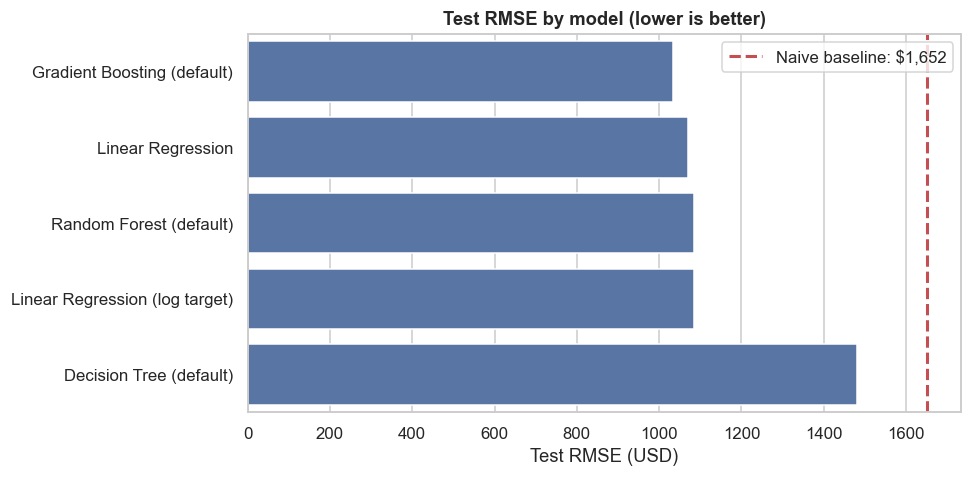

In [28]:
## Evaluate model - full scoreboard against the naive baseline

results = pd.DataFrame(scoreboard).sort_values('rmse').reset_index(drop=True)

# Express every model as an improvement over the do-nothing baseline, because 'RMSE 1043'
# means nothing on its own to a business reader.
baseline_rmse = results.loc[results['model'] == 'Naive baseline (mean)', 'rmse'].iloc[0]
baseline_mae = results.loc[results['model'] == 'Naive baseline (mean)', 'mae'].iloc[0]
results['rmse_vs_baseline_%'] = ((1 - results['rmse'] / baseline_rmse) * 100).round(1)
results['mae_vs_baseline_%'] = ((1 - results['mae'] / baseline_mae) * 100).round(1)

display(results.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = results[results['model'] != 'Naive baseline (mean)']
sns.barplot(data=plot_data, x='rmse', y='model', ax=ax, color='#4C72B0')
ax.axvline(baseline_rmse, color='#C44E52', ls='--', lw=2,
           label=f'Naive baseline: ${baseline_rmse:,.0f}')
ax.set_title('Test RMSE by model (lower is better)', fontweight='bold')
ax.set_xlabel('Test RMSE (USD)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()


## 5.2 Qualitative comparison — the overfitting gap

Test RMSE alone does not say whether a model is *trustworthy*. The distance between train and test error does: a model that scores far better on data it has seen has memorised rather than generalised, and its behaviour on genuinely new products is unpredictable. That matters commercially — this model will be asked about products and stores it has never seen.

Train vs test RMSE - a large positive gap means memorisation:

                         model  train_rmse   rmse  overfit_gap  gap_as_pct_of_test
   Gradient Boosting (default)      1038.0 1032.9         -5.1                -0.5
             Linear Regression      1141.6 1069.1        -72.5                -6.8
       Random Forest (default)       431.0 1083.9        653.0                60.2
Linear Regression (log target)      1151.3 1085.7        -65.6                -6.0
       Decision Tree (default)         0.0 1480.4       1480.4               100.0


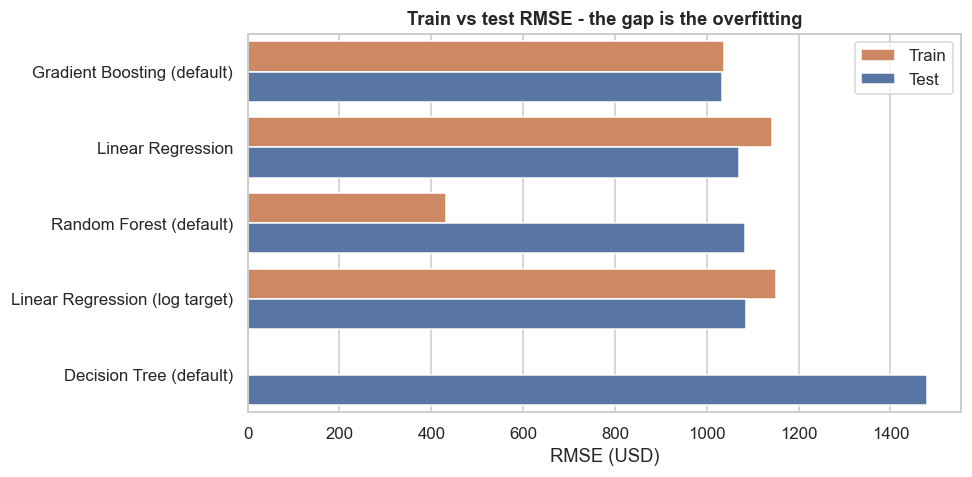

In [29]:
## How much better does each model do on data it has already seen?

gap = results[results['model'] != 'Naive baseline (mean)'].copy()
gap['overfit_gap'] = gap['rmse'] - gap['train_rmse']
gap['gap_as_pct_of_test'] = (gap['overfit_gap'] / gap['rmse'] * 100).round(1)

print('Train vs test RMSE - a large positive gap means memorisation:\n')
print(gap[['model', 'train_rmse', 'rmse', 'overfit_gap', 'gap_as_pct_of_test']]
      .round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
melted = gap.melt(id_vars='model', value_vars=['train_rmse', 'rmse'],
                  var_name='split', value_name='RMSE')
melted['split'] = melted['split'].map({'train_rmse': 'Train', 'rmse': 'Test'})
sns.barplot(data=melted, x='RMSE', y='model', hue='split', ax=ax,
            palette=['#DD8452', '#4C72B0'])
ax.set_title('Train vs test RMSE - the gap is the overfitting', fontweight='bold')
ax.set_xlabel('RMSE (USD)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()


## 5.3 Is the ranking real? Repeated cross-validation

A single 80/20 split gives one number per model, and that number carries sampling noise. If two models differ by less than that noise, preferring one over the other is superstition. Repeated 5-fold CV on the **training split only** gives a mean and a spread, so the ranking can be stated with a confidence interval instead of asserted.

In [30]:
## Repeated cross-validation on the training split

from sklearn.model_selection import RepeatedKFold, cross_val_score

# 5 folds x 3 repeats = 15 estimates per model, so the spread is measured rather than
# guessed. The test set is deliberately not involved.
rcv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

cv_candidates = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in cv_candidates.items():
    scores = -cross_val_score(bp.build_pipeline(model), X_train, y_train,
                              cv=rcv, scoring='neg_root_mean_squared_error')
    ci_low, ci_high = np.percentile(scores, [2.5, 97.5])
    cv_rows.append({'model': name, 'cv_rmse': scores.mean(), 'cv_std': scores.std(),
                    'ci_low': ci_low, 'ci_high': ci_high})
    print(f'{name:<20} CV RMSE {scores.mean():>8,.1f}  +/- {scores.std():>5,.1f}   '
          f'95% CI [{ci_low:,.1f}, {ci_high:,.1f}]')

cv_results = pd.DataFrame(cv_rows).sort_values('cv_rmse').reset_index(drop=True)
print()
display(cv_results.round(1))


Linear Regression    CV RMSE  1,148.0  +/-  24.9   95% CI [1,102.7, 1,183.2]


Decision Tree        CV RMSE  1,577.4  +/-  39.6   95% CI [1,522.4, 1,647.6]


Random Forest        CV RMSE  1,159.4  +/-  24.8   95% CI [1,114.8, 1,202.2]


Gradient Boosting    CV RMSE  1,098.9  +/-  26.8   95% CI [1,049.8, 1,137.2]



,model,cv_rmse,cv_std,ci_low,ci_high
0,Gradient Boosting,1098.9,26.8,1049.8,1137.2
1,Linear Regression,1148.0,24.9,1102.7,1183.2
2,Random Forest,1159.4,24.8,1114.8,1202.2
3,Decision Tree,1577.4,39.6,1522.4,1647.6


## 5.4 Quantifying the leakage we avoided

*(Added subsection.)* Section 3.1 claimed that fitting imputers before splitting inflates the score. Claims like that are cheap; here it is measured. The leaky version fits the **entire** preprocessor on all 8,523 rows and only then splits — so the medians and category lists used to fill the test rows were partly computed *from* the test rows. Everything else, including the split seed and the model, is held identical.

In [31]:
## Measure the optimism that leaky preprocessing would have bought us

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# WRONG ON PURPOSE: fit the preprocessor on every row, including the test rows.
leaky_prep = Pipeline([
    ('clean', FunctionTransformer(bp.clean_deterministic, validate=False)),
    ('weight', bp.ItemWeightImputer()),
    ('prep', bp.build_preprocessor(bp.NUMERIC_FEATURES, bp.CATEGORICAL_FEATURES)),
])
X_leaked = leaky_prep.fit_transform(X, y)

# Same seed, so the rows in each split are identical to the honest version above.
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leaked, y, test_size=0.2, random_state=RANDOM_STATE
)
leaky_model = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xl_train, yl_train)
leaky_rmse = root_mean_squared_error(yl_test, leaky_model.predict(Xl_test))

honest_rmse = results.loc[results['model'] == 'Gradient Boosting (default)',
                          'rmse'].iloc[0]

print(f'Leaky preprocessing  (fit on all data, then split): RMSE {leaky_rmse:,.1f}')
print(f'Honest preprocessing (fit inside the pipeline)    : RMSE {honest_rmse:,.1f}')
print(f'\nOptimism the leak would have bought: '
      f'${honest_rmse - leaky_rmse:,.1f} '
      f'({(honest_rmse - leaky_rmse) / honest_rmse * 100:.2f}% of RMSE)')


Leaky preprocessing  (fit on all data, then split): RMSE 1,036.3
Honest preprocessing (fit inside the pipeline)    : RMSE 1,032.9

Optimism the leak would have bought: $-3.3 (-0.32% of RMSE)


> ✏️ **TODO — read this result carefully before you quote it.**
>
> The measured difference came out close to zero. That is a real finding, not a broken experiment, and it is *not* evidence that leakage does not matter. Prompts for your write-up:
> - Why the effect is small **on this dataset specifically**: the leaked statistics are a >   median weight, a median visibility and a modal category. Computed over 6,818 rows or >   8,523 rows, how different would those three numbers actually be?
> - The number is within the fold-to-fold noise from §5.3 (±$25). What does that let you >   claim, and what does it *not* let you claim?
> - The argument that survives regardless: you could not have known the effect was small >   until you measured it, and on a dataset with group-level or time-ordered structure the >   same shortcut can inflate a score badly. Doing it correctly costs nothing here
> - **Do not** say 'this proves my pipeline has no leakage'. Say what you measured and >   over what


> ✏️ **TODO — model selection rationale (8% of the grade).** The rubric wants quantitative *and* qualitative comparison plus a clear reason for the choice. Prompts:
> - Which model wins on test RMSE, and by how much over the naive baseline in dollars >   and in percent?
> - Do the repeated-CV confidence intervals in §5.3 actually separate the top two, or do >   they overlap? Say so explicitly — it decides whether your 'best model' claim is real
> - Use the §5.2 gap table: which model memorised the training set? Name it and say why >   you rejected it even though its train error looked good
> - Beyond accuracy: interpretability, prediction latency in the app, retraining cost. >   Which would you trade accuracy for, and how much?
> - What the §5.4 number says about whether your headline score is honest
